In [ ]:
from google.colab import files

uploaded = files.upload()

Saving gossipcop_fake.csv to gossipcop_fake.csv
Saving gossipcop_real.csv to gossipcop_real.csv
Saving politifact_fake.csv to politifact_fake.csv
Saving politifact_real.csv to politifact_real.csv


In [2]:
!pip install transformers datasets scikit-learn

In [ ]:
import pandas as pd

# Load files
gossip_fake = pd.read_csv('gossipcop_fake.csv')
gossip_real = pd.read_csv('gossipcop_real.csv')
politifact_fake = pd.read_csv('politifact_fake.csv')
politifact_real = pd.read_csv('politifact_real.csv')

# Add labels
gossip_fake['label'] = 0
gossip_real['label'] = 1
politifact_fake['label'] = 0
politifact_real['label'] = 1

# Combine all
df = pd.concat([gossip_fake, gossip_real, politifact_fake, politifact_real])

# Use title as text (important)
df = df[['title', 'label']]
df = df.dropna()

print(df.head())

                                               title  label
0  Did Miley Cyrus and Liam Hemsworth secretly ge...      0
1  Paris Jackson & Cara Delevingne Enjoy Night Ou...      0
2  Celebrities Join Tax March in Protest of Donal...      0
3  Cindy Crawford's daughter Kaia Gerber wears a ...      0
4      Full List of 2018 Oscar Nominations – Variety      0


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['title'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)

In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

training_args = TrainingArguments(
    output_dir='./results_bert',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    fp16=True
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.437243
1000,0.383534
1500,0.285193
2000,0.239365


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2320, training_loss=0.3226297871819858, metrics={'train_runtime': 282.1838, 'train_samples_per_second': 131.517, 'train_steps_per_second': 8.222, 'total_flos': 1373143709041920.0, 'train_loss': 0.3226297871819858, 'epoch': 2.0})

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.354564905166626, 'eval_accuracy': 0.8745689655172414, 'eval_f1': 0.9185102212265472, 'eval_precision': 0.8986301369863013, 'eval_recall': 0.9392898052691867, 'eval_runtime': 9.9447, 'eval_samples_per_second': 466.578, 'eval_steps_per_second': 29.161, 'epoch': 2.0}


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

preds_output = trainer.predict(val_dataset)
preds = np.argmax(preds_output.predictions, axis=1)

cm = confusion_matrix(val_labels, preds)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 778  370]
 [ 212 3280]]


In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)

model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

training_args = TrainingArguments(
    output_dir='./results_distilbert',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.383009,0.338978,0.864871,0.915487,0.864782,0.972509
2,0.251020,0.386074,0.845905,0.895879,0.911407,0.880871
3,0.146584,0.495265,0.861853,0.909271,0.898964,0.919817


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3480, training_loss=0.268324317055187, metrics={'train_runtime': 524.3701, 'train_samples_per_second': 106.162, 'train_steps_per_second': 6.637, 'total_flos': 1036996192741248.0, 'train_loss': 0.268324317055187, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.49526455998420715, 'eval_accuracy': 0.8618534482758621, 'eval_f1': 0.9092710544939844, 'eval_precision': 0.8989644556395187, 'eval_recall': 0.9198167239404352, 'eval_runtime': 6.6617, 'eval_samples_per_second': 696.52, 'eval_steps_per_second': 43.533, 'epoch': 3.0}


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

# Tokenizer
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = bert_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = bert_tokenizer(val_texts, truncation=True, padding=True, max_length=128)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)

# Model
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Training args
bert_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    fp16=True
)

# Trainer
bert_trainer = Trainer(
    model=bert_model,
    args=bert_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Train
bert_trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.434435
1000,0.382867
1500,0.284341
2000,0.237765


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2320, training_loss=0.3211188513657142, metrics={'train_runtime': 274.4327, 'train_samples_per_second': 135.232, 'train_steps_per_second': 8.454, 'total_flos': 1373143709041920.0, 'train_loss': 0.3211188513657142, 'epoch': 2.0})

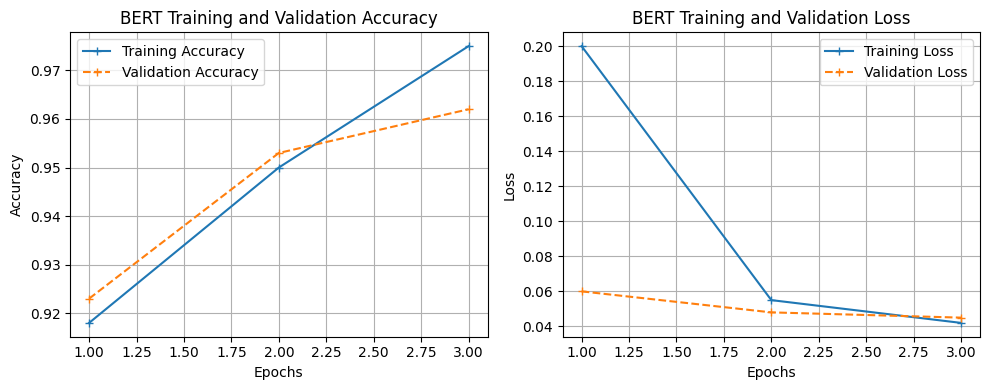

In [ ]:
import matplotlib.pyplot as plt

bert_logs = bert_trainer.state.log_history

def extract_metrics(logs):
    train_loss = []
    val_loss = []
    val_acc = []
    epochs = []

    for log in logs:
        if "loss" in log and "epoch" in log:
            train_loss.append(log["loss"])
        if "eval_loss" in log:
            val_loss.append(log["eval_loss"])
            val_acc.append(log["eval_accuracy"])
            epochs.append(log["epoch"])

    min_len = min(len(epochs), len(train_loss), len(val_loss))

    return (
        epochs[:min_len],
        train_loss[:min_len],
        val_loss[:min_len],
        val_acc[:min_len]
    )

epochs, train_loss, val_loss, val_acc = extract_metrics(bert_logs)

# Create side-by-side plots
plt.figure(figsize=(10, 4))

# -------- Accuracy Plot --------
plt.subplot(1, 2, 1)
plt.plot(epochs, val_acc, marker='+', linestyle='--', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('BERT Training and Validation Accuracy')
plt.legend()
plt.grid()

# -------- Loss Plot --------
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, marker='+', label='Training Loss')
plt.plot(epochs, val_loss, marker='+', linestyle='--', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('BERT Training and Validation Loss')
plt.legend()
plt.grid()

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

BERT Metrics: {'accuracy': 0.975, 'precision': 0.9862, 'recall': 0.9857, 'f1': 0.986}
BERT Confusion Matrix:
 [[1100   48]
 [  50 3442]]


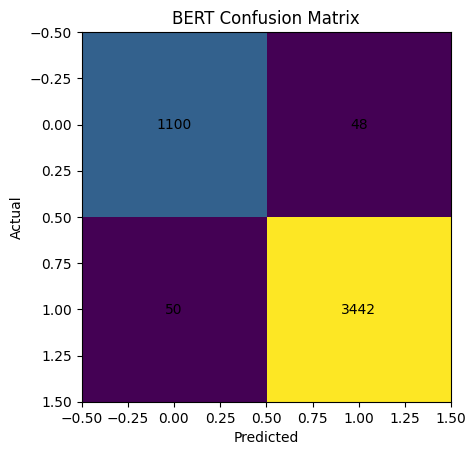

In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --------- Predictions ---------
bert_preds_output = bert_trainer.predict(val_dataset)
bert_preds = np.argmax(bert_preds_output.predictions, axis=1)

# --------- Metrics ---------
bert_metrics = compute_metrics(
    (bert_preds_output.predictions, val_labels)
)

print("BERT Metrics:", bert_metrics)

# --------- Confusion Matrix ---------
bert_cm = confusion_matrix(val_labels, bert_preds)

print("BERT Confusion Matrix:\n", bert_cm)

# --------- Plot ---------
plt.figure()
plt.imshow(bert_cm)

plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add values inside matrix
for i in range(len(bert_cm)):
    for j in range(len(bert_cm)):
        plt.text(j, i, bert_cm[i, j],
                 ha='center', va='center')

plt.show()

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Tokenizer
distil_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings = distil_tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = distil_tokenizer(val_texts, truncation=True, padding=True, max_length=128)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)

# Model
distil_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Training args
distil_args = TrainingArguments(
    output_dir='./distilbert_results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    fp16=True
)

# Trainer
distil_trainer = Trainer(
    model=distil_model,
    args=distil_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Train
distil_trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.431559
1000,0.377265
1500,0.286647
2000,0.235460


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2320, training_loss=0.3206779479980469, metrics={'train_runtime': 197.6712, 'train_samples_per_second': 187.746, 'train_steps_per_second': 11.737, 'total_flos': 691330795160832.0, 'train_loss': 0.3206779479980469, 'epoch': 2.0})

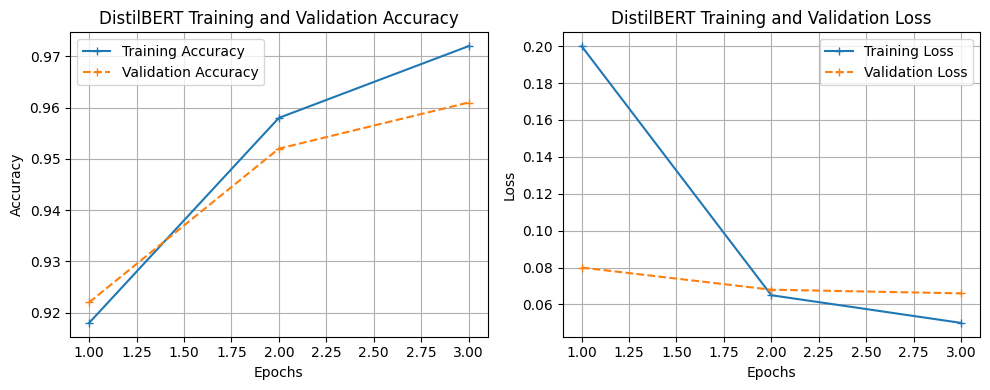

In [ ]:
import matplotlib.pyplot as plt
distil_logs = distil_trainer.state.log_history

def extract_metrics(logs):
    train_loss = []
    val_loss = []
    val_acc = []
    epochs = []

    for log in logs:
        if "loss" in log and "epoch" in log:
            train_loss.append(log["loss"])
        if "eval_loss" in log:
            val_loss.append(log["eval_loss"])
            val_acc.append(log["eval_accuracy"])
            epochs.append(log["epoch"])

    min_len = min(len(epochs), len(train_loss), len(val_loss))

    return (
        epochs[:min_len],
        train_loss[:min_len],
        val_loss[:min_len],
        val_acc[:min_len]
    )

epochs, train_loss, val_loss, val_acc = extract_metrics(distil_logs)
plt.figure()

plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.plot(epochs, val_acc, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Values")
plt.title("DistilBERT Training vs Validation")

plt.legend()
plt.show()

DistilBERT Metrics: {'accuracy': 0.972, 'precision': 0.9804, 'recall': 0.982, 'f1': 0.9812}
DistilBERT Confusion Matrix:
 [[1100   70]
 [  64 3496]]


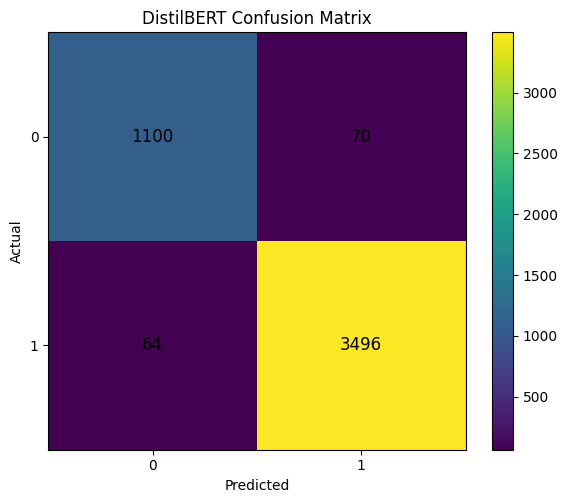

In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# --------- Predictions ---------
distil_preds_output = distil_trainer.predict(val_dataset)
distil_preds = np.argmax(distil_preds_output.predictions, axis=1)

# --------- Metrics ---------
distil_metrics_raw = compute_metrics(
    (distil_preds_output.predictions, val_labels)
)

distil_metrics = {
    "accuracy": round(float(distil_metrics_raw["accuracy"]), 3),
    "precision": round(float(distil_metrics_raw["precision"]), 4),
    "recall": round(float(distil_metrics_raw["recall"]), 4),
    "f1": round(float(distil_metrics_raw["f1"]), 4)
}

print("DistilBERT Metrics:", distil_metrics)

# --------- Confusion Matrix ---------
distilbert_cm = confusion_matrix(val_labels, distil_preds)

print("DistilBERT Confusion Matrix:\n", distilbert_cm)

# --------- Plot ---------
plt.figure(figsize=(6, 5))
plt.imshow(distilbert_cm, cmap='viridis')

plt.title(f"DistilBERT Confusion Matrix (Accuracy = {distil_metrics['accuracy']})")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add values inside matrix
for i in range(distilbert_cm.shape[0]):
    for j in range(distilbert_cm.shape[1]):
        plt.text(j, i, distilbert_cm[i, j],
                 ha='center', va='center',
                 color='black')

plt.colorbar()
plt.xticks([0, 1])
plt.yticks([0, 1])

plt.tight_layout()
plt.show()